# Security filters · 3. Lane policies

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ula-uab/lscm-decision-making/blob/main/cases/security_filters/notebooks/03_lane_policies.ipynb)

The decision: how many security lanes to open in each period of the day. More lanes mean shorter queues but more staff. A **policy** gives the open lanes by period; evaluating several policies on the curves of several demand scenarios gives a **decision table**.

In [1]:
# In Google Colab, install the package from GitHub (it takes a few seconds).
# On your own computer, install the repository environment instead (see README).
import sys
if "google.colab" in sys.modules:
    %pip install -q "git+https://github.com/ula-uab/lscm-decision-making#subdirectory=cases/security_filters"

In [2]:
import security_filters as sf
from security_filters.plots import plot_policy

schedule = sf.read_schedule()
day = sf.examples.DAY
flights = sf.flights_for_curve(schedule, day)
profiles = sf.profile_library()
scenarios = sf.examples.demand_scenarios()
curves = sf.demand_curves(scenarios, flights, profiles)

## 1. How the queue is computed

A lane serves a given number of passengers per hour (180 here, a provisional value). In each 5-minute slot the open lanes can serve up to `capacity` passengers; those who cannot be served wait for the next slot:

- served = min(capacity, queue of the previous slot + arrivals)
- queue = queue of the previous slot + arrivals − served

The indicators of a day are the maximum queue, the average and the maximum wait (minutes), the passenger-minutes spent waiting, and the **lane-hours**, which measure the cost of the policy.

## 2. A first guess

`lanes_to_cover` gives, for each period, the lanes needed to cover the arrivals of the busy slots of one curve. It ignores the queue, so it is a starting point, not an optimum.

In [3]:
periods = sf.examples.PERIODS
{name: sf.lanes_to_cover(curves[name], periods, quantile=0.8) for name in curves}

{'base': {'00:00-02:00': 2,
  '02:00-05:00': 19,
  '05:00-10:00': 25,
  '10:00-14:00': 23,
  '14:00-19:00': 25,
  '19:00-24:00': 8},
 'by flight type': {'00:00-02:00': 2,
  '02:00-05:00': 18,
  '05:00-10:00': 26,
  '10:00-14:00': 24,
  '14:00-19:00': 25,
  '19:00-24:00': 11},
 'cruise day': {'00:00-02:00': 2,
  '02:00-05:00': 18,
  '05:00-10:00': 26,
  '10:00-14:00': 26,
  '14:00-19:00': 23,
  '19:00-24:00': 11}}

## 3. The policies to compare

One policy opens 28 lanes all day; the others follow the first guess of each scenario. Add your own with `sf.LanePlan(name, {"HH:MM-HH:MM": lanes, ...})`.

In [4]:
policies = sf.examples.lane_policies(curves)
policies.append(sf.LanePlan("my plan", {"02:00-05:00": 20, "05:00-14:00": 28, "14:00-19:00": 27,
                                        "19:00-24:00": 14}, default_lanes=3))
for p in policies:
    print(f"{p.name:>28}: {p.lane_hours():.0f} lane-hours  {p.periods}")

                     flat 28: 600 lane-hours  {'02:00-23:00': 28}
               plan for base: 443 lane-hours  {'00:00-02:00': 2, '02:00-05:00': 19, '05:00-10:00': 25, '10:00-14:00': 23, '14:00-19:00': 25, '19:00-24:00': 8}
     plan for by flight type: 464 lane-hours  {'00:00-02:00': 2, '02:00-05:00': 18, '05:00-10:00': 26, '10:00-14:00': 24, '14:00-19:00': 25, '19:00-24:00': 11}
         plan for cruise day: 462 lane-hours  {'00:00-02:00': 2, '02:00-05:00': 18, '05:00-10:00': 26, '10:00-14:00': 26, '14:00-19:00': 23, '19:00-24:00': 11}
                     my plan: 523 lane-hours  {'02:00-05:00': 20, '05:00-14:00': 28, '14:00-19:00': 27, '19:00-24:00': 14}


## 4. Decision tables

One row per policy, one column per scenario. Lower is better for every indicator.

In [5]:
sf.decision_table(policies, curves, "max_wait_min").round(1)

scenario,lane_hours,base,by flight type,cruise day
policy,,,,
flat 28,600.0,10.6,1.6,2.9
plan for base,443.0,27.2,40.7,40.7
plan for by flight type,464.0,7.4,14.3,14.3
plan for cruise day,462.0,7.4,16.3,14.3
my plan,523.0,0.7,3.9,3.9


In [6]:
sf.decision_table(policies, curves, "waiting_pax_min").round(0)

scenario,lane_hours,base,by flight type,cruise day
policy,,,,
flat 28,600.0,3972.0,4181.0,9818.0
plan for base,443.0,58827.0,126970.0,199994.0
plan for by flight type,464.0,23417.0,48836.0,79819.0
plan for cruise day,462.0,50046.0,91667.0,67971.0
my plan,523.0,649.0,9248.0,14885.0


Two classic criteria for deciding without knowing which scenario will happen:

- **worst case** (pessimistic): choose the policy whose worst result is best;
- **maximum regret**: in each scenario, how much worse a policy is than the best one for that scenario; choose the policy whose largest regret is smallest.

Both ignore the cost, so read them together with the lane-hours.

In [7]:
table = sf.decision_table(policies, curves, "max_wait_min")
comparison = table[["lane_hours"]].join(sf.worst_case(table)).join(sf.regret(table)["max_regret"])
comparison.round(1)

,lane_hours,worst_case,max_regret
policy,,,
flat 28,600.0,10.6,10.0
plan for base,443.0,40.7,39.2
plan for by flight type,464.0,14.3,12.7
plan for cruise day,462.0,16.3,14.7
my plan,523.0,3.9,2.3


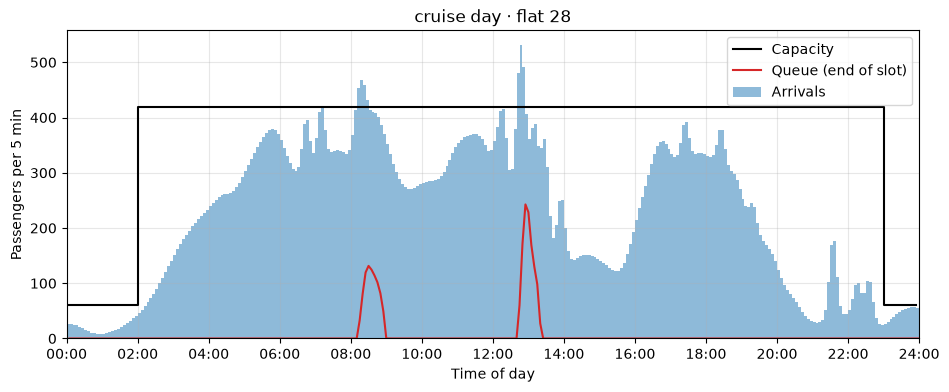

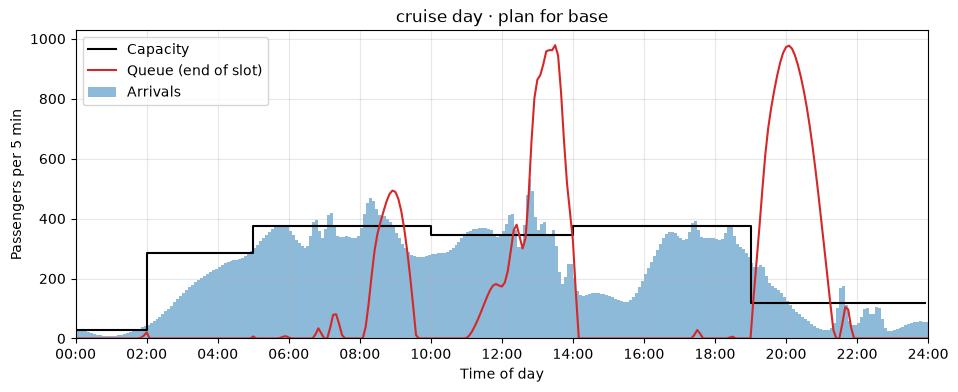

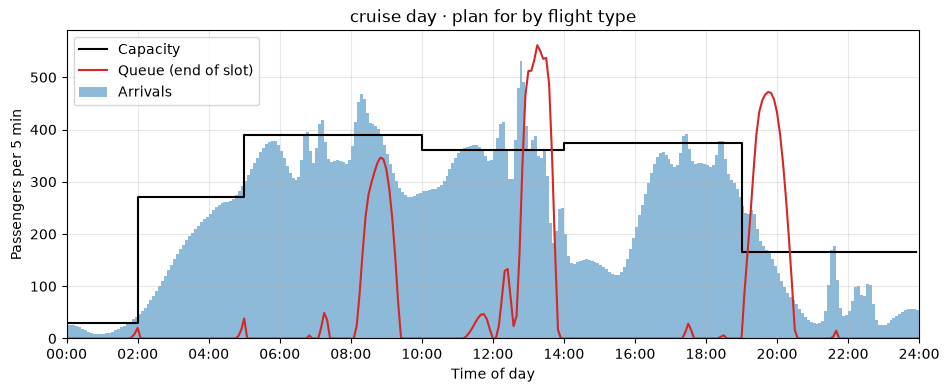

In [8]:
cruise_curve = curves["cruise day"]
for p in policies[:3]:
    plot_policy(cruise_curve, p)

## 5. Try it yourself

- Find the cheapest policy (fewest lane-hours) that keeps the maximum wait below 15 minutes in every scenario.
- Change the capacity of a lane (`pax_per_lane_hour`) and see which policies still work.
- Which policy would you choose, and why?

Notebook 4 checks the policies against what really happened on the day.